Saving data.csv to data (1).csv
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'
unzip:  cannot find or open breast-cancer-wisconsin-data.zip, breast-cancer-wisconsin-data.zip.zip or breast-cancer-wisconsi

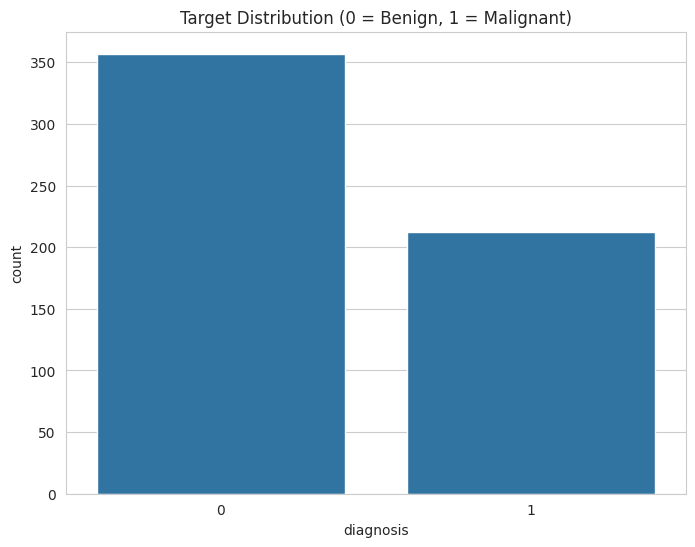

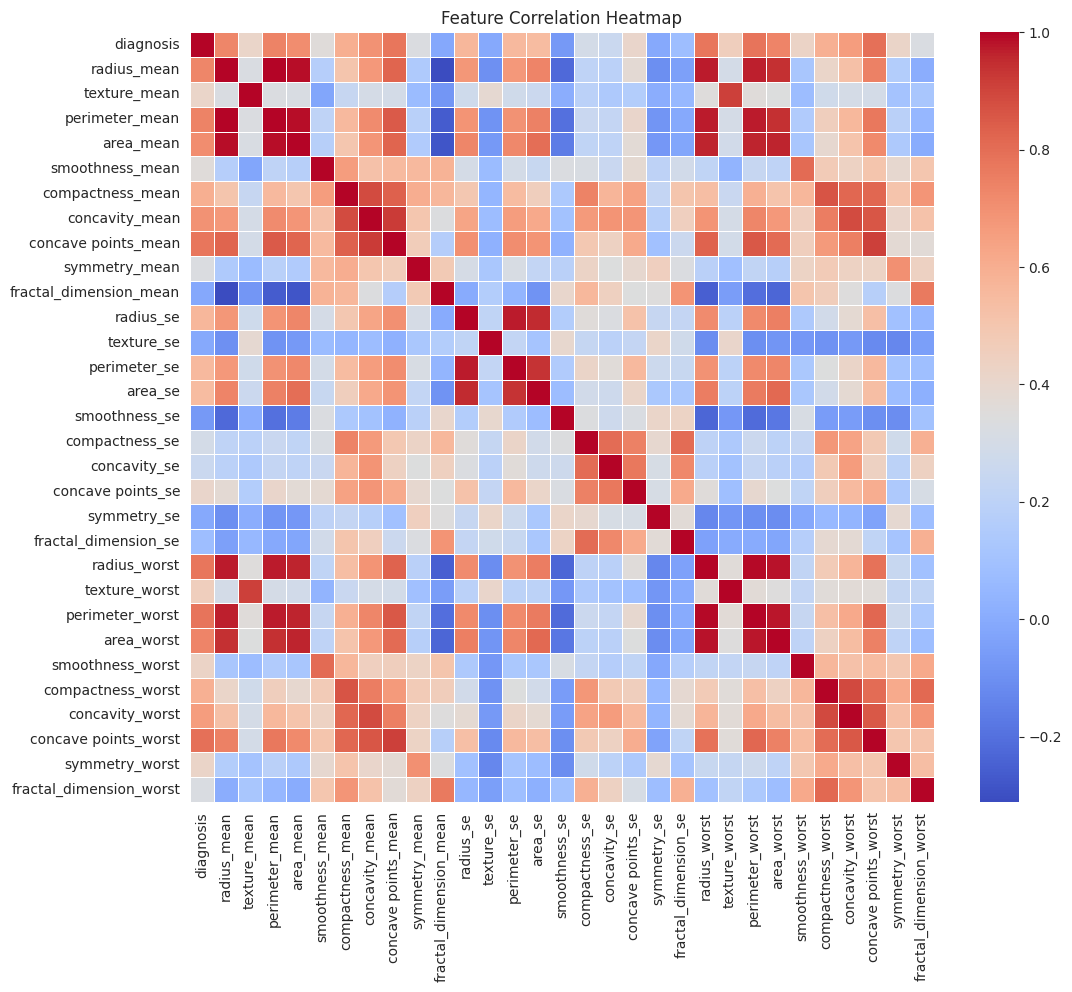

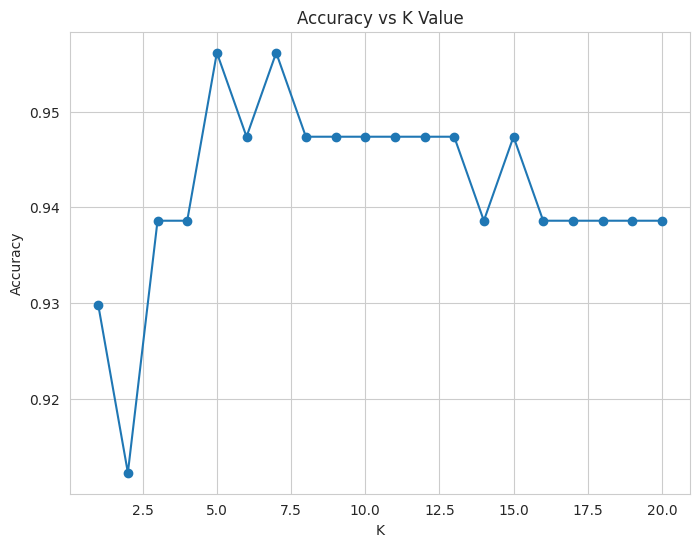

Best K Value: 5
Best Accuracy: 0.956140350877193

Final Model Accuracy: 0.956140350877193

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



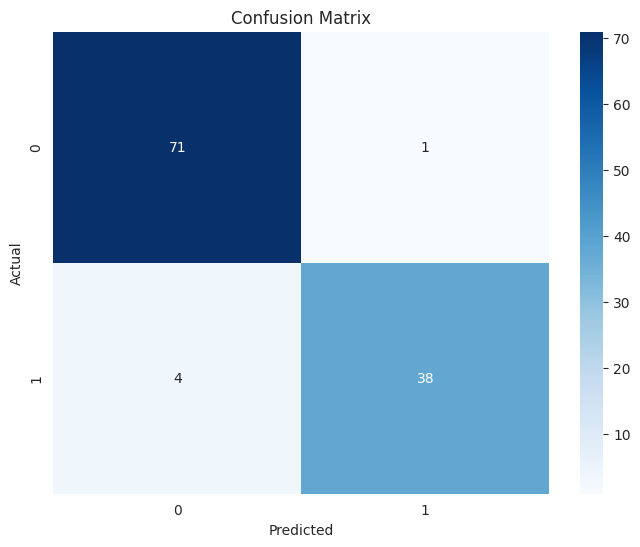

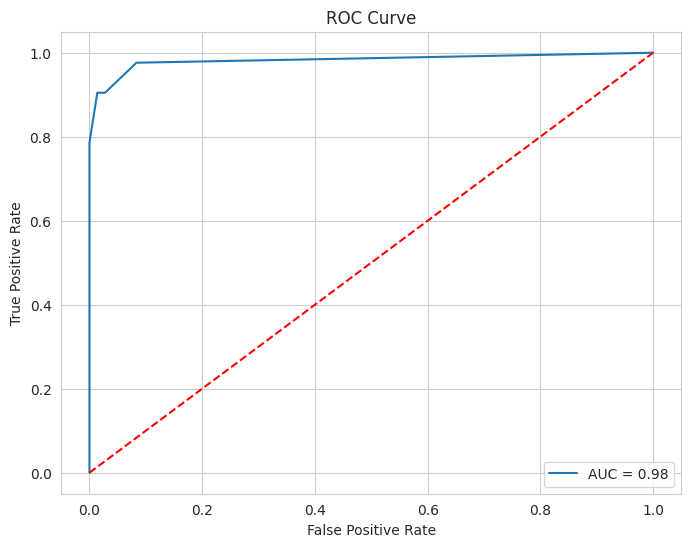

ROC AUC Score: 0.982308201058201


In [1]:
# ==========================================================
# K-NEAREST NEIGHBORS (KNN) IMPLEMENTATION - FULL PROJECT
# Breast Cancer Classification (Kaggle Dataset)
# ==========================================================

# -------------------------------
# STEP 1: Install & Setup Kaggle
# -------------------------------
!pip install -q kaggle

from google.colab import files
files.upload()  # Upload kaggle.json here

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d uciml/breast-cancer-wisconsin-data
!unzip breast-cancer-wisconsin-data.zip


# -------------------------------
# STEP 2: Import Libraries
# -------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,6)


# -------------------------------
# STEP 3: Load Dataset
# -------------------------------
df = pd.read_csv("data.csv")

print("Dataset Shape:", df.shape)
df.head()


# -------------------------------
# STEP 4: Data Cleaning
# -------------------------------
df = df.drop(['id', 'Unnamed: 32'], axis=1)

# Convert target column
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})

print("\nMissing Values:\n", df.isnull().sum().sum())


# -------------------------------
# STEP 5: Data Visualization
# -------------------------------

# Target Distribution
sns.countplot(x='diagnosis', data=df)
plt.title("Target Distribution (0 = Benign, 1 = Malignant)")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


# -------------------------------
# STEP 6: Split Features & Target
# -------------------------------
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# -------------------------------
# STEP 7: Feature Scaling
# -------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# -------------------------------
# STEP 8: Finding Optimal K
# -------------------------------
accuracy_scores = []
k_values = range(1, 21)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, preds))

plt.plot(k_values, accuracy_scores, marker='o')
plt.title("Accuracy vs K Value")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

best_k = k_values[np.argmax(accuracy_scores)]
print("Best K Value:", best_k)
print("Best Accuracy:", max(accuracy_scores))


# -------------------------------
# STEP 9: Train Final KNN Model
# -------------------------------
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)


# -------------------------------
# STEP 10: Model Evaluation
# -------------------------------

print("\nFinal Model Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# -------------------------------
# STEP 11: ROC Curve
# -------------------------------
y_prob = knn.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print("ROC AUC Score:", roc_auc)